



1/1 [==============================] - 3s 3s/step
Raw Predictions: [[3.0559534e-02 9.6818906e-01 1.1266434e-03 5.4508797e-05 7.0316230e-05]]
Decoded Predictions: [[('common_krait', 0.96818906)]]


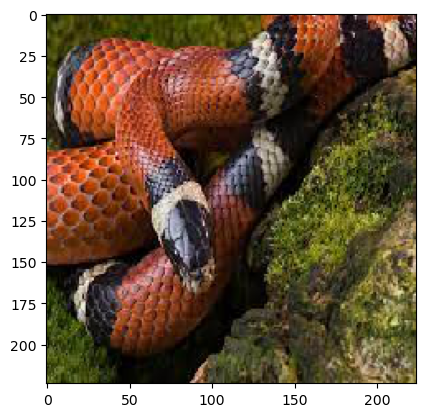

In [1]:
import numpy as np
from keras.preprocessing.image import load_img, img_to_array
from keras.models import load_model
import matplotlib.pyplot as plt
from keras.applications.densenet import preprocess_input

def decode_predictions_specific(preds, top=1, class_list=None):
    results = []
    for pred in preds:
        top_indices = pred.argsort()[-top:][::-1]
        result = [(class_list[i], pred[i]) for i in top_indices]
        results.append(result)
    return results



1/1 [==============================] - 2s 2s/step
Raw Predictions: [[1.2855383e-04 5.3860556e-05 2.0858666e-04 9.9954516e-01 6.3841064e-05]]
Decoded Predictions: [[('russells_viper', 0.99954516)]]


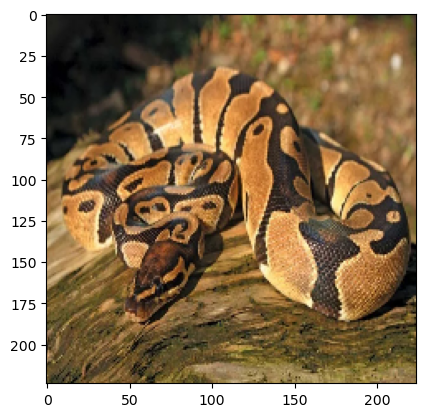

In [11]:
def predict_with_densenet(image_path):
    model = load_model('densenet121-ft.model')

    # Load and preprocess the image
    original = load_img(image_path, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)
    processed_image = preprocess_input(image_batch.copy())

    # Make predictions
    predictions = model.predict(processed_image)
    print('Raw Predictions:', predictions)

    # Decode predictions (get the class labels)
    class_list = ["cobra", "common_krait", "hump_nosed_pit_viper", "russells_viper", "Saw_Scaled_Viper"]
    decoded_predictions = decode_predictions_specific(predictions, top=1, class_list=class_list)
    print('Decoded Predictions:', decoded_predictions)

    # Display the image
    plt.imshow(original)
    plt.show()

# Example usage
image_path = "16.jpg"
predict_with_densenet(image_path)
